In [1]:
import optuna
import numpy as np
import pandas as pd
import warnings
import seaborn as sns
import matplotlib.pyplot as plt

from gg_boosting import PTCMBoost
from lifelines import KaplanMeierFitter
from utils import integrated_brier_score, kaplan_meier, monte_carlo_mse, monte_carlo_bias
from km_gg import GG_KM
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, train_test_split

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")

In [3]:
def cross_validate_gg_km(
    X,
    t,
    delta,
    kernel="rbf",
    n_outer_splits=5,
    n_inner_splits=4,
    n_trials=50,
    t_grid_points=50,
    random_state=42,
):

    outer_cv = KFold(
        n_splits=n_outer_splits,
        shuffle=True,
        random_state=random_state
    )

    all_test_ibs = []
    all_best_params = []

    print(f"{'='*60}")
    print(f" Nested CV: {n_outer_splits} outer × {n_inner_splits} inner folds")
    print(f" Kernel: {kernel}")
    print(f" Optuna trials per fold: {n_trials}")
    print(f"{'='*60}\n")

    for fold_idx, (train_idx, test_idx) in enumerate(outer_cv.split(X)):

        print(
            f"─── Outer fold {fold_idx + 1}/{n_outer_splits} ",
            end="",
            flush=True
        )

        X_outer_train, X_test = X[train_idx], X[test_idx]
        t_outer_train, t_test = t[train_idx], t[test_idx]
        d_outer_train, d_test = delta[train_idx], delta[test_idx]

        t_lo = np.percentile(t_outer_train, 5)
        t_hi = np.percentile(t_outer_train, 95)
        t_grid = np.linspace(t_lo, t_hi, t_grid_points)

        inner_cv = KFold(
            n_splits=n_inner_splits,
            shuffle=True,
            random_state=random_state
        )

        def objective(trial):

            params = {
                "lambda_reg": trial.suggest_float(
                    "lambda_reg",
                    1e-5,
                    1.0,
                    log=True
                )
            }

            if kernel in {
                "rbf",
                "gaussian",
                "laplacian",
                "exponential",
                "cauchy",
                "sigmoid",
            }:
                params["gamma"] = trial.suggest_float(
                    "gamma",
                    1e-3,
                    10.0,
                    log=True
                )

            if kernel == "polynomial":
                params["gamma"] = trial.suggest_float(
                    "gamma",
                    1e-3,
                    10.0,
                    log=True
                )

                params["degree"] = trial.suggest_int(
                    "degree",
                    2,
                    6
                )

                params["coef0"] = trial.suggest_float(
                    "coef0",
                    0.0,
                    5.0
                )

            if kernel == "sigmoid":
                params["coef0"] = trial.suggest_float(
                    "coef0",
                    -5.0,
                    5.0
                )

            val_scores = []

            for tr_idx, val_idx in inner_cv.split(X_outer_train):

                X_tr, X_val = (
                    X_outer_train[tr_idx],
                    X_outer_train[val_idx]
                )

                t_tr, t_val = (
                    t_outer_train[tr_idx],
                    t_outer_train[val_idx]
                )

                d_tr, d_val = (
                    d_outer_train[tr_idx],
                    d_outer_train[val_idx]
                )

                scaler = StandardScaler()

                X_tr_s = scaler.fit_transform(X_tr)
                X_val_s = scaler.transform(X_val)

                t_grid_inner = np.linspace(
                    np.percentile(t_tr, 5),
                    np.percentile(t_tr, 95),
                    t_grid_points
                )

                try:

                    model = GG_KM(
                        kernel=kernel,
                        **params
                    )

                    model.fit(X_tr_s, t_tr, d_tr)

                    S_pred = model.predict_survival(
                        X_val_s,
                        t_grid_inner
                    )

                    ibs = integrated_brier_score(
                        S_pred,
                        t_val,
                        d_val,
                        t_tr,
                        d_tr,
                        t_grid_inner
                    )

                    val_scores.append(ibs)

                except Exception:
                    return 1.0

            return float(np.mean(val_scores))

        study = optuna.create_study(
            direction="minimize",
            sampler=optuna.samplers.TPESampler(
                seed=random_state
            ),
        )

        study.optimize(
            objective,
            n_trials=n_trials,
            show_progress_bar=False
        )

        best_params = study.best_params

        print(
            f"→ best val IBS = {study.best_value:.4f}"
        )

        scaler = StandardScaler()

        X_outer_train_s = scaler.fit_transform(
            X_outer_train
        )

        X_test_s = scaler.transform(
            X_test
        )

        final_model = GG_KM(
            kernel=kernel,
            **best_params
        )

        final_model.fit(
            X_outer_train_s,
            t_outer_train,
            d_outer_train
        )

        S_test = final_model.predict_survival(
            X_test_s,
            t_grid
        )

        test_ibs = integrated_brier_score(
            S_test,
            t_test,
            d_test,
            t_outer_train,
            d_outer_train,
            t_grid
        )

        print(
            f"           test IBS = {test_ibs:.4f}\n"
        )

        all_test_ibs.append(test_ibs)
        all_best_params.append(best_params)

    print(f"{'='*60}")
    print(" Cross-Validation Results")
    print(f"{'='*60}")
    print(f" IBS per fold : {[f'{v:.4f}' for v in all_test_ibs]}")
    print(f" Mean IBS     : {np.mean(all_test_ibs):.4f}")
    print(f" Std  IBS     : {np.std(all_test_ibs):.4f}")
    print(f"{'='*60}\n")

    return {
        "test_ibs": all_test_ibs,
        "mean_ibs": float(np.mean(all_test_ibs)),
        "std_ibs": float(np.std(all_test_ibs)),
        "best_params": all_best_params,
    }

In [ ]:
# def generate_wsvcr_data(n=500, censoring_rate=0.3, random_state=None):
#     if random_state is not None:
#         np.random.seed(random_state)

#     x1 = np.random.normal(1, 1, n)
#     x2 = np.random.normal(2, np.sqrt(2), n)
#     x3 = np.random.exponential(1, n)

#     x2_safe = np.where(np.abs(x2) < 1e-8, 1e-8, x2)

#     lam = 5 * np.exp(
#         -x1 * np.log(np.abs(x2_safe)) + np.sin(x3 ** 2)
#     )

#     k = 3
#     U = np.random.uniform(0, 1, n)
#     Y = lam * (-np.log1p(-U)) ** (1 / k)

#     def generate_censoring(Y, target_rate):
#         scale = np.median(Y)

#         for _ in range(50):
#             C = np.random.exponential(scale=scale, size=len(Y))
#             delta = (Y <= C).astype(int)

#             observed_censoring = 1 - delta.mean()

#             if abs(observed_censoring - target_rate) < 0.01:
#                 return C

#             scale *= 1.2 if observed_censoring > target_rate else 0.8

#         return C

#     C = generate_censoring(Y, censoring_rate)

#     T = np.minimum(Y, C)
#     delta = (Y <= C).astype(int)

#     return pd.DataFrame({
#         "X1": x1,
#         "X2": x2,
#         "X3": x3,
#         "T": T,
#         "delta": delta
#     })

In [75]:
melanoma = (
    pd.read_csv("../data/melanoma.csv")
    .assign(status=lambda x: (x.status == 1).astype(int))
    .fillna(0)
)

y = melanoma[["time", "status"]]

X_raw = melanoma.drop(columns=y.columns.tolist()).to_numpy()

t = y["time"].to_numpy().astype(float)
delta = y["status"].to_numpy().astype(float)

kernels = [
    "linear",
    "rbf",
    "laplacian",
    "exponential",
    "cauchy",
    "sigmoid",
    "polynomial",
]

all_results = {}

for kernel in kernels:

    print("\n")
    print("=" * 80)
    print(f"Kernel: {kernel}")
    print("=" * 80)

    results = cross_validate_gg_km(
        X_raw,
        t,
        delta,
        n_outer_splits=5,
        n_inner_splits=4,
        n_trials=20,
        t_grid_points=50,
        random_state=42,
        kernel=kernel,
    )

    all_results[kernel] = results

print("\n")
print("=" * 80)
print("FINAL SUMMARY")
print("=" * 80)

for kernel, res in all_results.items():
    print(
        f"{kernel:12s} "
        f"Mean IBS = {res['mean_ibs']:.4f} "
        f"± {res['std_ibs']:.4f}"
    )



Kernel: linear
 Nested CV: 5 outer × 4 inner folds
 Kernel: linear
 Optuna trials per fold: 20

─── Outer fold 1/5 → best val IBS = 0.1737
           test IBS = 0.1135

─── Outer fold 2/5 → best val IBS = 0.1441
           test IBS = 0.1509

─── Outer fold 3/5 → best val IBS = 0.1721
           test IBS = 0.1652

─── Outer fold 4/5 → best val IBS = 0.1549
           test IBS = 0.1990

─── Outer fold 5/5 → best val IBS = 0.1688
           test IBS = 0.1301

 Cross-Validation Results
 IBS per fold : ['0.1135', '0.1509', '0.1652', '0.1990', '0.1301']
 Mean IBS     : 0.1517
 Std  IBS     : 0.0295



Kernel: rbf
 Nested CV: 5 outer × 4 inner folds
 Kernel: rbf
 Optuna trials per fold: 20

─── Outer fold 1/5 → best val IBS = 0.1686
           test IBS = 0.1186

─── Outer fold 2/5 → best val IBS = 0.1466
           test IBS = 0.1513

─── Outer fold 3/5 

non-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fraction

→ best val IBS = 0.1669
           test IBS = 0.1744

─── Outer fold 4/5 → best val IBS = 0.1445
           test IBS = 0.2059

─── Outer fold 5/5 → best val IBS = 0.1588
           test IBS = 0.1309

 Cross-Validation Results
 IBS per fold : ['0.1186', '0.1513', '0.1744', '0.2059', '0.1309']
 Mean IBS     : 0.1562
 Std  IBS     : 0.0312



Kernel: laplacian
 Nested CV: 5 outer × 4 inner folds
 Kernel: laplacian
 Optuna trials per fold: 20

─── Outer fold 1/5 

non-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fraction

→ best val IBS = 0.1505
           test IBS = 0.1387

─── Outer fold 2/5 

...

→ best val IBS = 0.1424
           test IBS = 0.1823

─── Outer fold 5/5 

non-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fraction

→ best val IBS = 0.1656
           test IBS = 0.1232

 Cross-Validation Results
 IBS per fold : ['0.1400', '0.1786', '0.1690', '0.1823', '0.1232']
 Mean IBS     : 0.1586
 Std  IBS     : 0.0231



Kernel: polynomial
 Nested CV: 5 outer × 4 inner folds
 Kernel: polynomial
 Optuna trials per fold: 20

─── Outer fold 1/5 → best val IBS = 0.1598
           test IBS = 0.1155

─── Outer fold 2/5 → best val IBS = 0.1415
           test IBS = 0.1496

─── Outer fold 3/5 

non-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fractionnon-convergence in pg_continued_fraction

→ best val IBS = 0.1631
           test IBS = 0.1795

─── Outer fold 4/5 → best val IBS = 0.1545
           test IBS = 0.1945

─── Outer fold 5/5 → best val IBS = 0.1679
           test IBS = 0.1304

 Cross-Validation Results
 IBS per fold : ['0.1155', '0.1496', '0.1795', '0.1945', '0.1304']
 Mean IBS     : 0.1539
 Std  IBS     : 0.0295



FINAL SUMMARY
linear       Mean IBS = 0.1517 ± 0.0295
rbf          Mean IBS = 0.1562 ± 0.0312
laplacian    Mean IBS = 0.1584 ± 0.0192
exponential  Mean IBS = 0.1536 ± 0.0170
cauchy       Mean IBS = 0.1663 ± 0.0439
sigmoid      Mean IBS = 0.1586 ± 0.0231
polynomial   Mean IBS = 0.1539 ± 0.0295


In [128]:
all_results

{'linear': {'test_ibs': [np.float64(0.11349992181427114),
   np.float64(0.15087323327446062),
   np.float64(0.16522152271276846),
   np.float64(0.19900359954727548),
   np.float64(0.13012400592910411)],
  'mean_ibs': 0.15174445665557595,
  'std_ibs': 0.029481876674972308,
  'best_params': [{'lambda_reg': 0.974217634211552},
   {'lambda_reg': 0.7897219752341905},
   {'lambda_reg': 0.9012852407949292},
   {'lambda_reg': 0.86607490542954},
   {'lambda_reg': 0.974217634211552}]},
 'rbf': {'test_ibs': [np.float64(0.11856166964515484),
   np.float64(0.15133730602931786),
   np.float64(0.17441458291707068),
   np.float64(0.20585325647678135),
   np.float64(0.13085400491005691)],
  'mean_ibs': 0.15620416399567633,
  'std_ibs': 0.03124076181705548,
  'best_params': [{'lambda_reg': 0.8192602279031006,
    'gamma': 0.023739423955292542},
   {'lambda_reg': 0.567005066101662, 'gamma': 0.026810157533840164},
   {'lambda_reg': 0.8192602279031006, 'gamma': 0.023739423955292542},
   {'lambda_reg': 6.02

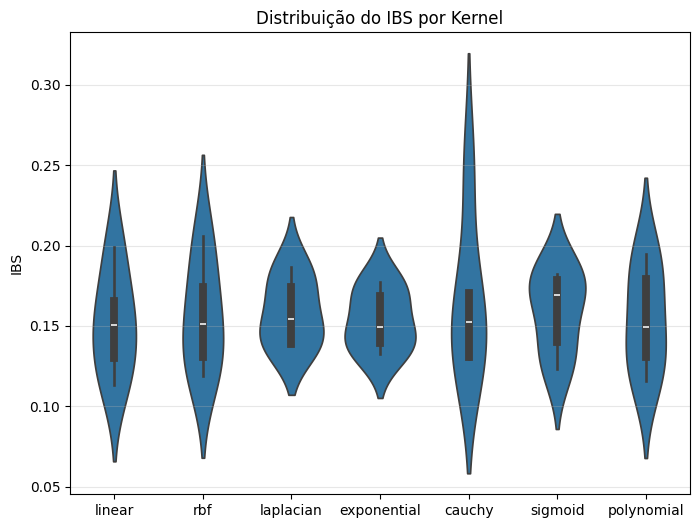

In [88]:
data = []

for kernel, results in all_results.items():
    for ibs in results["test_ibs"]:
        data.append({
            "kernel": kernel,
            "test_ibs": ibs
        })

df_plot = pd.DataFrame(data)

plt.figure(figsize=(8, 6))

sns.violinplot(
    data=df_plot,
    x="kernel",
    y="test_ibs",
    inner="box"
)

# plt.xlabel("Kernel")
plt.xlabel("")
plt.ylabel("IBS")
plt.title("Distribuição do IBS por Kernel")
plt.grid(axis="y", alpha=0.3)

plt.show()

In [131]:
import pandas as pd

summary = []

for kernel, results in all_results.items():
    summary.append({
        "kernel": kernel,
        "mean_ibs": results["mean_ibs"],
        "std_ibs": results["std_ibs"]
    })

df_summary = (
    pd.DataFrame(summary)
    .sort_values("mean_ibs")
    .reset_index(drop=True)
)

print(df_summary.T)

                 0            1           2         3          4         5  \
kernel      linear  exponential  polynomial       rbf  laplacian   sigmoid   
mean_ibs  0.151744      0.15356    0.153894  0.156204   0.158353  0.158627   
std_ibs   0.029482     0.017049    0.029465  0.031241   0.019249  0.023082   

                 6  
kernel      cauchy  
mean_ibs  0.166336  
std_ibs   0.043864  


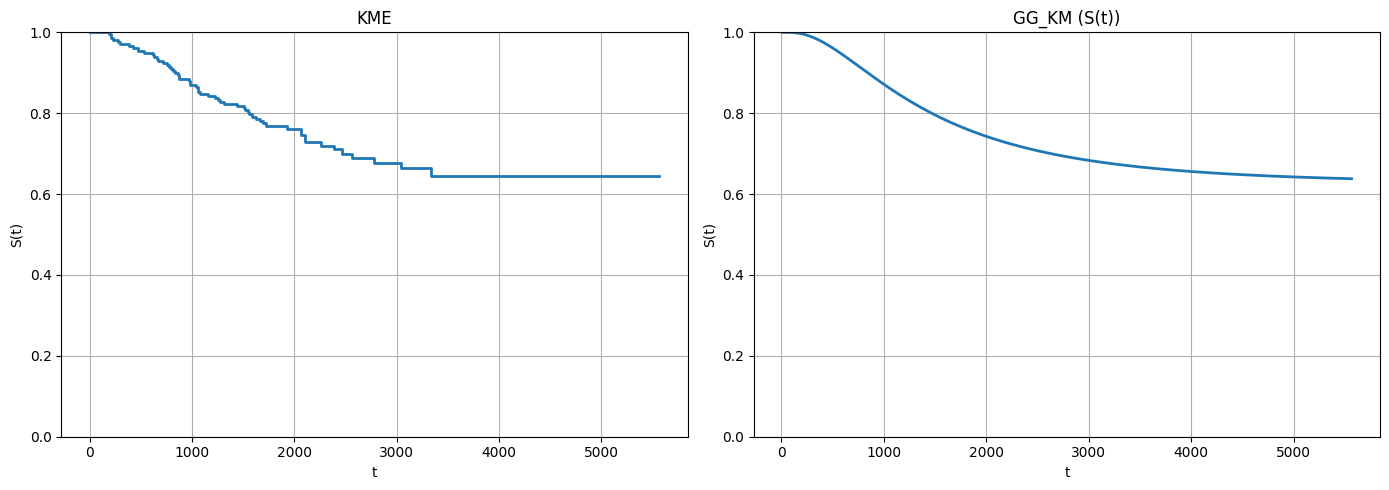

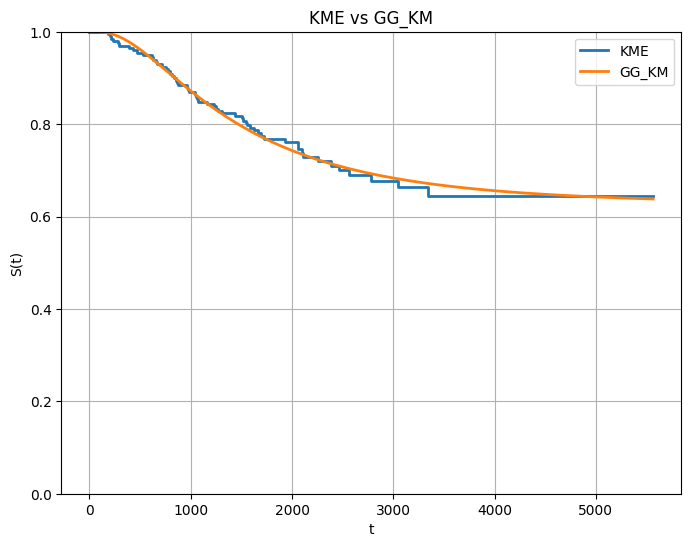

In [78]:
melanoma = (
    pd.read_csv("../data/melanoma.csv")
    .assign(status=lambda x: (x.status == 1).astype(int))
    .fillna(0)
)

y = melanoma[["time", "status"]]

X_raw = melanoma.drop(columns=y.columns.tolist()).to_numpy()

t = y["time"].to_numpy().astype(float)
delta = y["status"].to_numpy().astype(float)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

model = GG_KM(
    kernel="cauchy",
    lambda_reg=0.009163741808778781,
    gamma=0.0015339162591163618,
    degree=5,
    coef0=0.8526206184364576
)

model.fit(X_scaled, t, delta)


km_t, km_s = kaplan_meier(t, delta)


t_grid = np.linspace(
    np.min(t),
    np.max(t),
    300
)

S_pred = model.predict_survival(
    X_scaled,
    t_grid
)

S_mean = S_pred.mean(axis=0)


fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)


axes[0].step(
    km_t,
    km_s,
    where="post",
    linewidth=2
)

axes[0].set_ylim(0,1)
axes[0].set_title("KME")
axes[0].set_xlabel("t")
axes[0].set_ylabel("S(t)")
axes[0].grid(True)

axes[1].plot(
    t_grid,
    S_mean,
    linewidth=2
)
axes[1].set_ylim(0,1)

axes[1].set_title("GG_KM (S(t))")
axes[1].set_xlabel("t")
axes[1].set_ylabel("S(t)")
axes[1].grid(True)

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))

plt.step(
    km_t,
    km_s,
    where="post",
    linewidth=2,
    label="KME"
)

plt.plot(
    t_grid,
    S_mean,
    linewidth=2,
    label="GG_KM"
)

plt.ylim(0, 1)
plt.xlabel("t")
plt.ylabel("S(t)")
plt.title("KME vs GG_KM")
plt.legend()
plt.grid(True)

plt.show()

In [5]:
def pi_method(x1, x2, method):
    if method == 1:
        eta = 0.3 - 5*x1 - 3*x2
        return np.exp(eta) / (1 + np.exp(eta))

    elif method == 2:
        eta = 0.3 + 5*(x1**2) - 3*(x2**2)
        return np.exp(eta) / (1 + np.exp(eta))

    elif method == 3:
        eta = 0.3 - 5*np.cos(x1) - 3*np.sin(x2)
        return np.exp(-np.exp(eta))

    else:
        raise ValueError("method must be 1, 2, or 3")


def weibull_inverse(u, alpha, beta1, beta2, z1, z2):
    linpred = beta1*z1 + beta2*z2
    return ((-np.log(u)) / np.exp(linpred))**(1/alpha)


def simulate_pcm(n=300, method=1,
                 alpha=2, beta1=1, beta2=0.5,
                 censor_rate=0.2, seed=None):

    if seed is not None:
        np.random.seed(seed)

    x1 = np.random.normal(size=n)
    x2 = np.random.normal(size=n)

    z1 = x1.copy()
    z2 = x2.copy()

    pi_x = pi_method(x1, x2, method)

    t = np.zeros(n)
    delta = np.zeros(n, dtype=int)
    cured = np.zeros(n, dtype=int)

    for i in range(n):

        U = np.random.uniform()
        C = np.random.exponential(scale=1/censor_rate)

        if U <= (1 - pi_x[i]):
            t[i] = C
            delta[i] = 0
            cured[i] = 1

        else:
            U1 = np.random.uniform(1 - pi_x[i], 1)

            v = np.log(U1) / np.log(1 - pi_x[i])

            y = weibull_inverse(
                u=v,
                alpha=alpha,
                beta1=beta1,
                beta2=beta2,
                z1=z1[i],
                z2=z2[i]
            )

            t[i] = min(y, C)

            if y <= C:
                delta[i] = 1
            else:
                delta[i] = 0

    df = pd.DataFrame({
        "time": t,
        "event": delta,
        "x1": x1,
        "x2": x2,
        "z1": z1,
        "z2": z2,
        "pi_x": pi_x,
        "cured": cured
    })

    return df


df = simulate_pcm(
    n=600,
    method=3,
    alpha=2,
    beta1=1,
    beta2=0.5,
    seed=42
)

train_df, test_df = train_test_split(
    df,
    test_size=1/3,
    random_state=42
)

print(df.head())

print("\nCure fraction:", df["cured"].mean())
print("Censoring proportion:", 1 - df["event"].mean())
print("Events:", df["event"].sum())

       time  event        x1        x2        z1        z2      pi_x  cured
0  1.417218      1  0.496714  0.756989  0.496714  0.756989  0.997881      0
1  2.354406      1 -0.138264 -0.922165 -0.138264 -0.922165  0.901055      0
2  0.920206      1  0.647689  0.869606  0.647689  0.869606  0.997473      0
3  0.611199      1  1.523030  1.355638  1.523030  1.355638  0.944855      0
4  1.351638      0 -0.234153  0.413435 -0.234153  0.413435  0.996881      0

Cure fraction: 0.22833333333333333
Censoring proportion: 0.42500000000000004
Events: 345


In [ ]:
# kernels = [
#     "linear",
#     "rbf",
#     "laplacian",
#     "exponential",
#     "cauchy",
#     "sigmoid",
#     "polynomial",
# ]

# sample_sizes = [300, 600]
# methods = [1, 2, 3]

# experiment_results = {}

# for n in sample_sizes:

#     experiment_results[n] = {}

#     for method in methods:

#         print("\n")
#         print("=" * 100)
#         print(f"SIMULATION SETTING → n={n} | method={method}")
#         print("=" * 100)

#         df = simulate_pcm(
#             n=n,
#             method=method,
#             alpha=2,
#             beta1=1,
#             beta2=0.5,
#             seed=42
#         )

#         X_raw = df[["x1", "x2"]].to_numpy()

#         t = df["time"].to_numpy().astype(float)
#         delta = df["event"].to_numpy().astype(float)

#         experiment_results[n][method] = {}

#         for kernel in kernels:

#             print("\n")
#             print("-" * 80)
#             print(f"Kernel: {kernel}")
#             print("-" * 80)

#             results = cross_validate_gg_km(
#                 X=X_raw,
#                 t=t,
#                 delta=delta,
#                 kernel=kernel,
#                 n_outer_splits=5,
#                 n_inner_splits=4,
#                 n_trials=20,
#                 t_grid_points=50,
#                 random_state=42,
#             )

#             experiment_results[n][method][kernel] = results

In [6]:
def cross_validate_pcm(
    n,
    method,
    kernel="rbf",
    n_outer_splits=5,
    n_inner_splits=4,
    n_trials=20,
    t_grid_points=50,
    random_state=42,
):

    df = simulate_pcm(
        n=n,
        method=method,
        seed=random_state
    )

    X = df[["x1", "x2"]].to_numpy()
    t = df["time"].to_numpy()
    delta = df["event"].to_numpy()

    p_cure_true = 1 - df["pi_x"].to_numpy()

    outer_cv = KFold(
        n_splits=n_outer_splits,
        shuffle=True,
        random_state=random_state
    )

    all_test_ibs = []
    all_bias = []
    all_mse = []
    all_best_params = []

    print(f"\n{'='*80}")
    print(f"n={n} | Method={method} | Kernel={kernel}")
    print(f"{'='*80}")

    for fold_idx, (train_idx, test_idx) in enumerate(outer_cv.split(X)):

        print(f"Outer fold {fold_idx + 1}/{n_outer_splits}")

        X_outer_train, X_test = X[train_idx], X[test_idx]
        t_outer_train, t_test = t[train_idx], t[test_idx]
        d_outer_train, d_test = delta[train_idx], delta[test_idx]

        p_cure_test_true = p_cure_true[test_idx]

        t_grid = np.linspace(
            np.percentile(t_outer_train, 5),
            np.percentile(t_outer_train, 95),
            t_grid_points
        )

        inner_cv = KFold(
            n_splits=n_inner_splits,
            shuffle=True,
            random_state=random_state
        )

        def objective(trial):

            params = {
                "lambda_reg": trial.suggest_float(
                    "lambda_reg",
                    1e-5,
                    1.0,
                    log=True
                )
            }

            if kernel != "linear":
                params["gamma"] = trial.suggest_float(
                    "gamma",
                    1e-3,
                    10.0,
                    log=True
                )

            if kernel == "polynomial":
                params["degree"] = trial.suggest_int(
                    "degree",
                    2,
                    6
                )

                params["coef0"] = trial.suggest_float(
                    "coef0",
                    0.0,
                    5.0
                )

            if kernel == "sigmoid":
                params["coef0"] = trial.suggest_float(
                    "coef0",
                    -5.0,
                    5.0
                )

            val_scores = []

            for tr_idx, val_idx in inner_cv.split(X_outer_train):

                X_tr = X_outer_train[tr_idx]
                X_val = X_outer_train[val_idx]

                t_tr = t_outer_train[tr_idx]
                t_val = t_outer_train[val_idx]

                d_tr = d_outer_train[tr_idx]
                d_val = d_outer_train[val_idx]

                scaler = StandardScaler()

                X_tr_s = scaler.fit_transform(X_tr)
                X_val_s = scaler.transform(X_val)

                t_grid_inner = np.linspace(
                    np.percentile(t_tr, 5),
                    np.percentile(t_tr, 95),
                    t_grid_points
                )

                try:
                    model = GG_KM(
                        kernel=kernel,
                        **params
                    )

                    model.fit(X_tr_s, t_tr, d_tr)

                    S_pred = model.predict_survival(
                        X_val_s,
                        t_grid_inner
                    )

                    ibs = integrated_brier_score(
                        S_pred,
                        t_val,
                        d_val,
                        t_tr,
                        d_tr,
                        t_grid_inner
                    )

                    val_scores.append(ibs)

                except Exception:
                    return 1.0

            return float(np.mean(val_scores))

        study = optuna.create_study(
            direction="minimize",
            sampler=optuna.samplers.TPESampler(
                seed=random_state
            )
        )

        study.optimize(
            objective,
            n_trials=n_trials,
            show_progress_bar=False
        )

        best_params = study.best_params
        all_best_params.append(best_params)

        scaler = StandardScaler()

        X_train_s = scaler.fit_transform(X_outer_train)
        X_test_s = scaler.transform(X_test)

        final_model = GG_KM(
            kernel=kernel,
            **best_params
        )

        final_model.fit(
            X_train_s,
            t_outer_train,
            d_outer_train
        )

        S_test = final_model.predict_survival(
            X_test_s,
            t_grid
        )

        test_ibs = integrated_brier_score(
            S_test,
            t_test,
            d_test,
            t_outer_train,
            d_outer_train,
            t_grid
        )

        all_test_ibs.append(test_ibs)

        p_cure_hat = final_model.predict_cure_probability(
            X_test_s
        )

        fold_bias = np.mean(
            p_cure_hat - p_cure_test_true
        )

        fold_mse = np.mean(
            (p_cure_hat - p_cure_test_true) ** 2
        )

        all_bias.append(fold_bias)
        all_mse.append(fold_mse)

        print(
            f"IBS={test_ibs:.4f} | "
            f"Bias={fold_bias:.4f} | "
            f"MSE={fold_mse:.4f}"
        )

    return {
        "test_ibs": all_test_ibs,
        "mean_ibs": float(np.mean(all_test_ibs)),
        "std_ibs": float(np.std(all_test_ibs)),
        "mean_bias": float(np.mean(all_bias)),
        "std_bias": float(np.std(all_bias)),
        "mean_mse": float(np.mean(all_mse)),
        "std_mse": float(np.std(all_mse)),
        "best_params": all_best_params
    }

In [ ]:
kernels = [
    "linear",
    "rbf",
    "laplacian",
    "exponential",
    "cauchy",
    "sigmoid",
    "polynomial",
]

sample_sizes = [300, 600]
methods = [1, 2, 3]

experiment_results = {}

for n in sample_sizes:

    experiment_results[n] = {}

    for method in methods:

        print("\n")
        print("=" * 100)
        print(f"SIMULATION SETTING → n={n} | method={method}")
        print("=" * 100)

        experiment_results[n][method] = {}

        for kernel in kernels:

            print("\n")
            print("-" * 80)
            print(f"Kernel: {kernel}")
            print("-" * 80)

            results = cross_validate_pcm(
                n=n,
                method=method,
                kernel=kernel,
                n_outer_splits=5,
                n_inner_splits=4,
                n_trials=20,
                t_grid_points=50,
                random_state=42,
            )

            experiment_results[n][method][kernel] = results

In [119]:
summary_rows = []

for n in experiment_results.columns:
    for method in experiment_results.index:

        kernel_results = eval(experiment_results.loc[method, n])

        best_kernel = min(
            kernel_results.keys(),
            key=lambda k: kernel_results[k]["mean_ibs"]
        )

        best_metrics = kernel_results[best_kernel]

        summary_rows.append({
            "sample_size": n,
            "method": method,
            "best_kernel": best_kernel,
            "mean_ibs": best_metrics["mean_ibs"],
            "std_ibs": best_metrics["std_ibs"],
            "mean_bias": best_metrics["mean_bias"],
            "std_bias": best_metrics["std_bias"],
            "mean_mse": best_metrics["mean_mse"],
            "std_mse": best_metrics["std_mse"]
        })

summary_table = pd.DataFrame(summary_rows)

In [121]:
summary_table

,sample_size,method,best_kernel,mean_ibs,std_ibs,mean_bias,std_bias,mean_mse,std_mse
0,300,1,cauchy,0.119817,0.039458,-0.022888,0.031022,0.026384,0.007392
1,300,2,cauchy,0.156419,0.028950,0.057410,0.025101,0.070955,0.013773
2,300,3,exponential,0.129544,0.018073,-0.010330,0.023532,0.022034,0.015945
3,600,1,sigmoid,0.102708,0.025662,0.021040,0.019272,0.036263,0.021153
4,600,2,rbf,0.145632,0.041263,-0.004345,0.026232,0.030669,0.010342
5,600,3,polynomial,0.086305,0.028084,-0.004270,0.021587,0.019165,0.008394


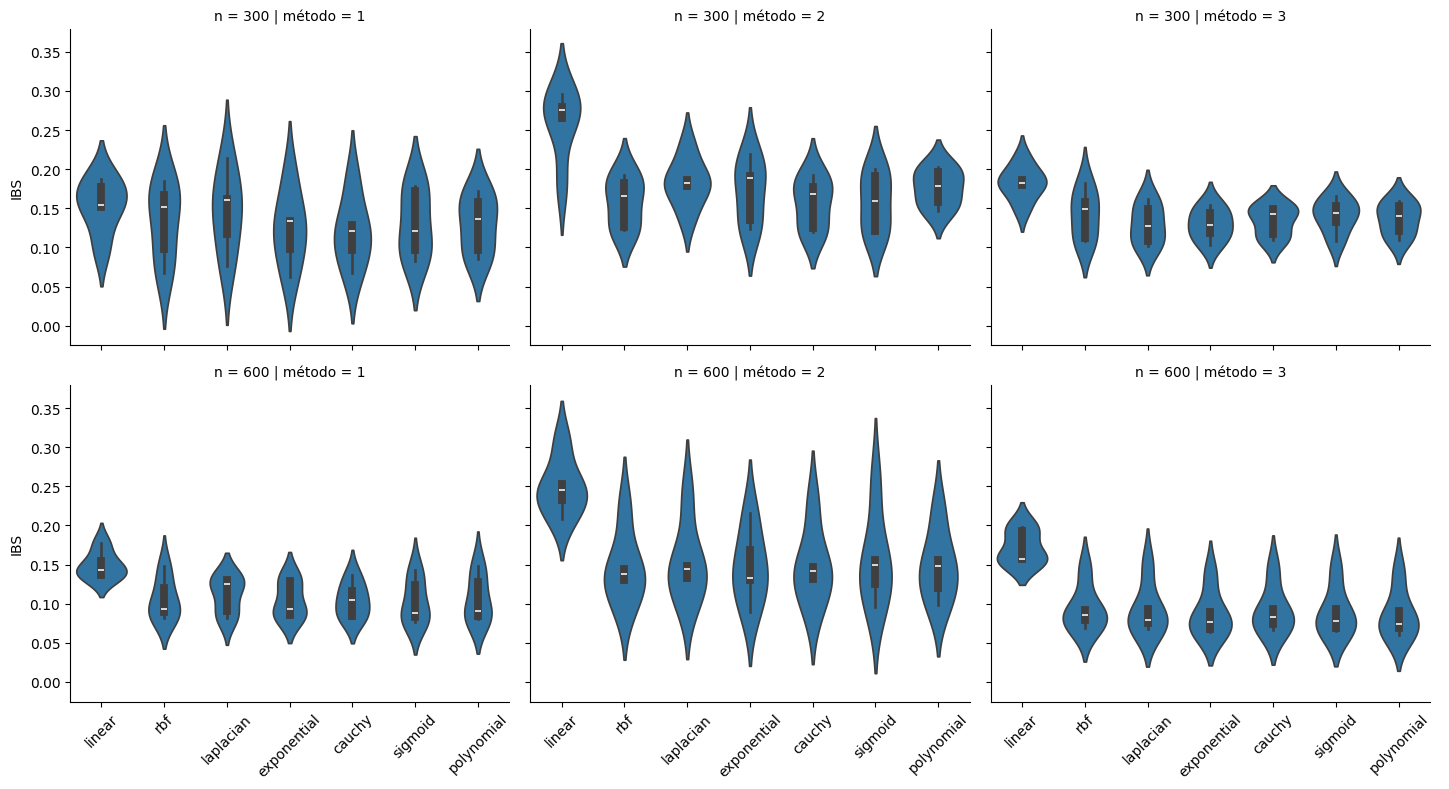

In [112]:
data = []

for sample_size, methods in experiment_results.items():
    for method_id, kernels in methods.items():
        if isinstance(kernels, str):
            kernels = eval(kernels)

        for kernel_name, results in kernels.items():
            for ibs in results["test_ibs"]:
                data.append({
                    "n": sample_size,
                    "método": method_id,
                    "kernel": kernel_name,
                    "test_ibs": float(ibs)
                })

df_plot = pd.DataFrame(data)

df_plot["kernel"] = df_plot["kernel"].astype("category")

kernel_order = df_plot["kernel"].unique()

g = sns.catplot(
    data=df_plot,
    x="kernel",
    y="test_ibs",
    row="n",
    col="método",
    kind="violin",
    inner="box",
    order=kernel_order,
    height=4,
    aspect=1.2
)

for ax in g.axes.flat:
    ax.tick_params(axis="x", rotation=45)
    ax.set_ylabel("IBS")
    ax.set_xlabel("")

plt.tight_layout()
plt.show()

In [113]:
experiment_results = pd.read_csv("experiment_results.csv")
experiment_results.index = range(1, 4)

def plot_best_survival_curves(
    experiment_results,
    sample_sizes,
    methods,
    t_grid_points=100,
    random_state=42,
):

    n_rows = len(sample_sizes)
    n_cols = len(methods)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(6 * n_cols, 5 * n_rows),
        squeeze=False
    )

    for i, n in enumerate(sample_sizes):
        for j, method in enumerate(methods):

            ax = axes[i, j]

            kernel_results = eval(experiment_results[str(n)][method])

            best_kernel = min(
                kernel_results.keys(),
                key=lambda k: kernel_results[k]["mean_ibs"]
            )

            best_params = kernel_results[best_kernel]["best_params"][0]

            print(f"\nn={n} | method={method}")
            print(f"Best kernel: {best_kernel}")
            print(f"Best IBS: {kernel_results[best_kernel]['mean_ibs']:.4f}")

            df = simulate_pcm(
                n=n,
                method=method,
                alpha=2,
                beta1=1,
                beta2=0.5,
                seed=random_state
            )

            X = df[["x1", "x2"]].to_numpy()
            t = df["time"].to_numpy().astype(float)
            delta = df["event"].to_numpy().astype(float)

            scaler = StandardScaler()
            X_scaled = scaler.fit_transform(X)

            model = GG_KM(
                kernel=best_kernel,
                **best_params
            )

            model.fit(X_scaled, t, delta)

            t_grid = np.linspace(
                np.min(t),
                np.max(t),
                t_grid_points
            )

            S_pred = model.predict_survival(
                X_scaled,
                t_grid
            )

            S_mean = S_pred.mean(axis=0)

            kmf = KaplanMeierFitter()
            kmf.fit(
                durations=t,
                event_observed=delta
            )

            # Kaplan-Meier
            kmf.plot_survival_function(
                ax=ax,
                ci_show=False
            )

            # GG_KM
            ax.plot(
                t_grid,
                S_mean,
                linewidth=2,
                label=f"GG_KM ({best_kernel})"
            )

            ax.set_title(
                f"n={n} | método={method}"
            )

            ax.set_xlabel("t")
            ax.set_ylabel("S(t)")
            ax.set_ylim(0, 1)
            ax.grid(True)
            ax.legend()

    plt.tight_layout()
    plt.show()

# def plot_best_survival_curves(
#     experiment_results,
#     sample_sizes,
#     methods,
#     t_grid_points=100,
#     random_state=42,
# ):

#     for n in sample_sizes:
#         for method in methods:

#             kernel_results = eval(experiment_results[str(n)][method])

#             best_kernel = min(
#                 kernel_results.keys(),
#                 key=lambda k: kernel_results[k]["mean_ibs"]
#             )

#             best_params = kernel_results[best_kernel]["best_params"][0]

#             print(f"\nn={n} | method={method}")
#             print(f"Best kernel: {best_kernel}")
#             print(f"Best IBS: {kernel_results[best_kernel]['mean_ibs']:.4f}")

#             df = simulate_pcm(
#                 n=n,
#                 method=method,
#                 alpha=2,
#                 beta1=1,
#                 beta2=0.5,
#                 seed=random_state
#             )

#             X = df[["x1", "x2"]].to_numpy()
#             t = df["time"].to_numpy().astype(float)
#             delta = df["event"].to_numpy().astype(float)

#             scaler = StandardScaler()
#             X_scaled = scaler.fit_transform(X)

#             model = GG_KM(
#                 kernel=best_kernel,
#                 **best_params
#             )

#             model.fit(X_scaled, t, delta)

#             t_grid = np.linspace(
#                 np.percentile(t, 0),
#                 np.percentile(t, 100),
#                 t_grid_points
#             )

#             S_pred = model.predict_survival(
#                 X_scaled,
#                 # t,
#                 t_grid
#             )

#             S_mean = S_pred.mean(axis=0)

#             kmf = KaplanMeierFitter()
#             kmf.fit(
#                 durations=t,
#                 event_observed=delta
#             )

#             plt.figure(figsize=(8, 6))

#             kmf.plot_survival_function()

#             plt.plot(
#                 t_grid,
#                 S_mean,
#                 linewidth=2,
#                 label=f"GG_KM ({best_kernel})"
#             )

#             plt.title(
#                 f"n={n} | método={method}"
#             )

#             plt.xlabel("t")
#             plt.ylabel("S(t)")

#             plt.ylim(0, 1)

#             plt.legend()
#             plt.grid(True)
#             plt.show()


n=300 | method=1
Best kernel: cauchy
Best IBS: 0.1198

n=300 | method=2
Best kernel: cauchy
Best IBS: 0.1564

n=300 | method=3
Best kernel: exponential
Best IBS: 0.1295

n=600 | method=1
Best kernel: sigmoid
Best IBS: 0.1027

n=600 | method=2
Best kernel: rbf
Best IBS: 0.1456

n=600 | method=3
Best kernel: polynomial
Best IBS: 0.0863


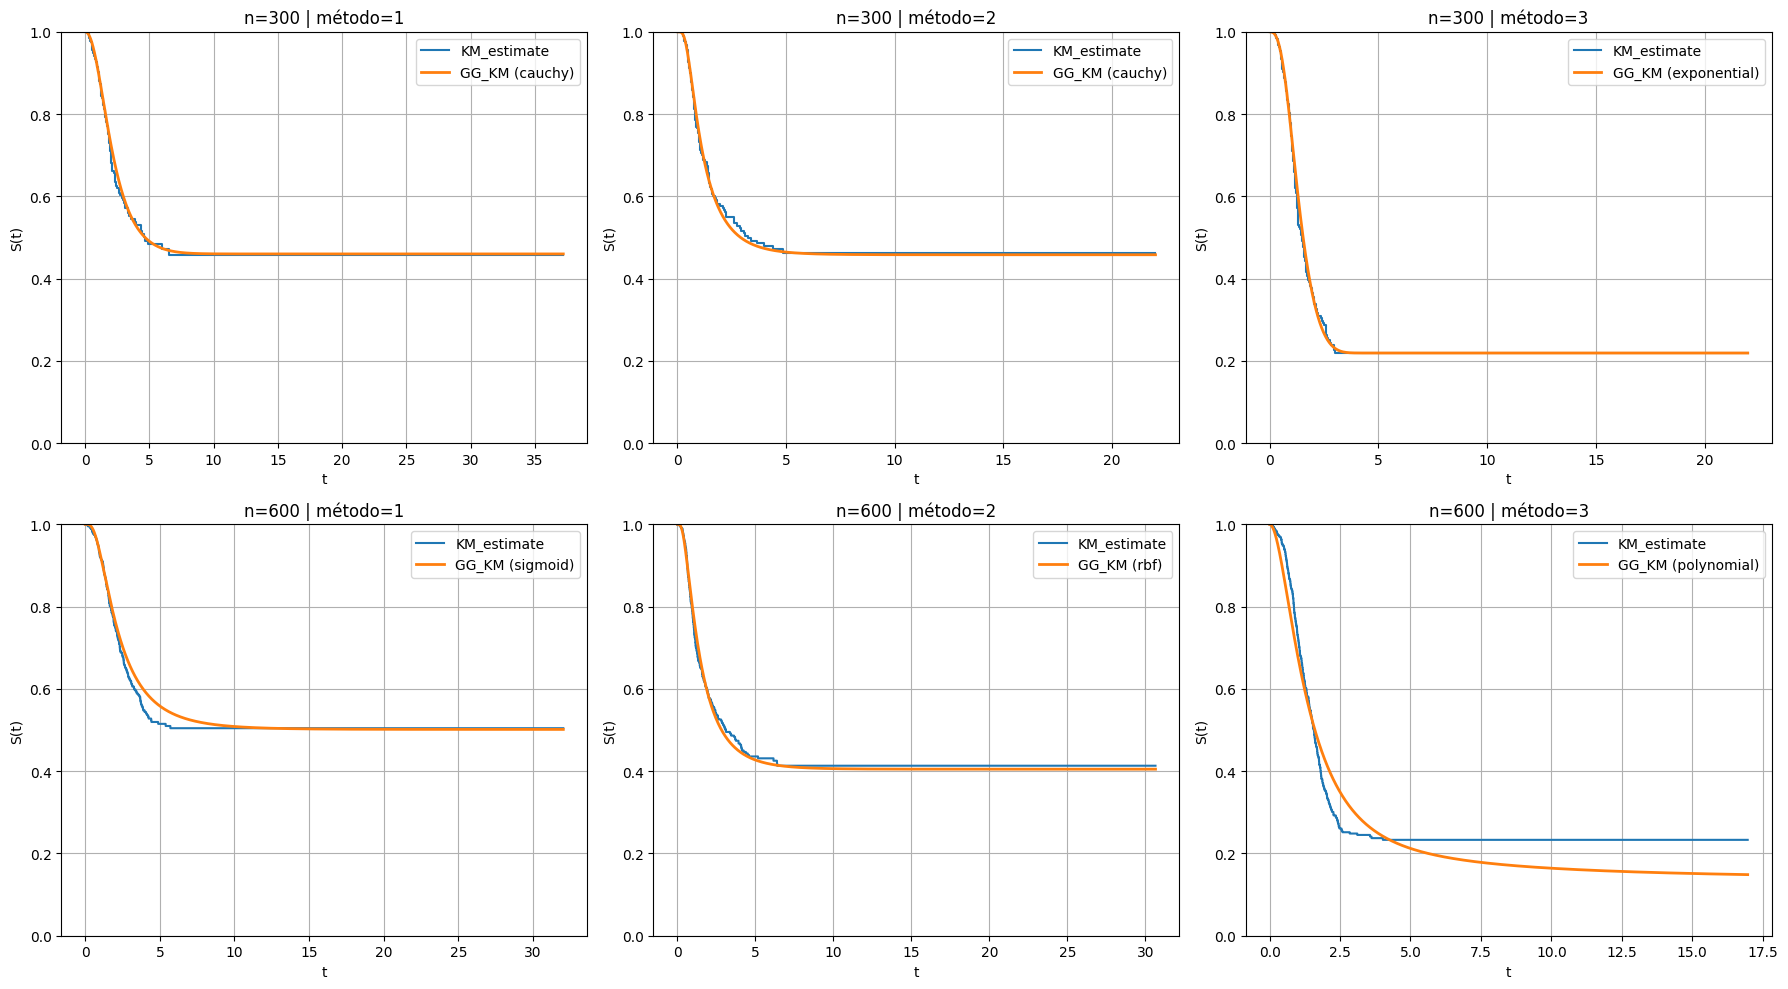

In [114]:
plot_best_survival_curves(
    experiment_results=experiment_results,
    sample_sizes=[300, 600],
    methods=[1, 2, 3],
    t_grid_points=1000
)

In [ ]:
# pd.DataFrame(experiment_results).to_csv("experiment_results.csv", index=False)

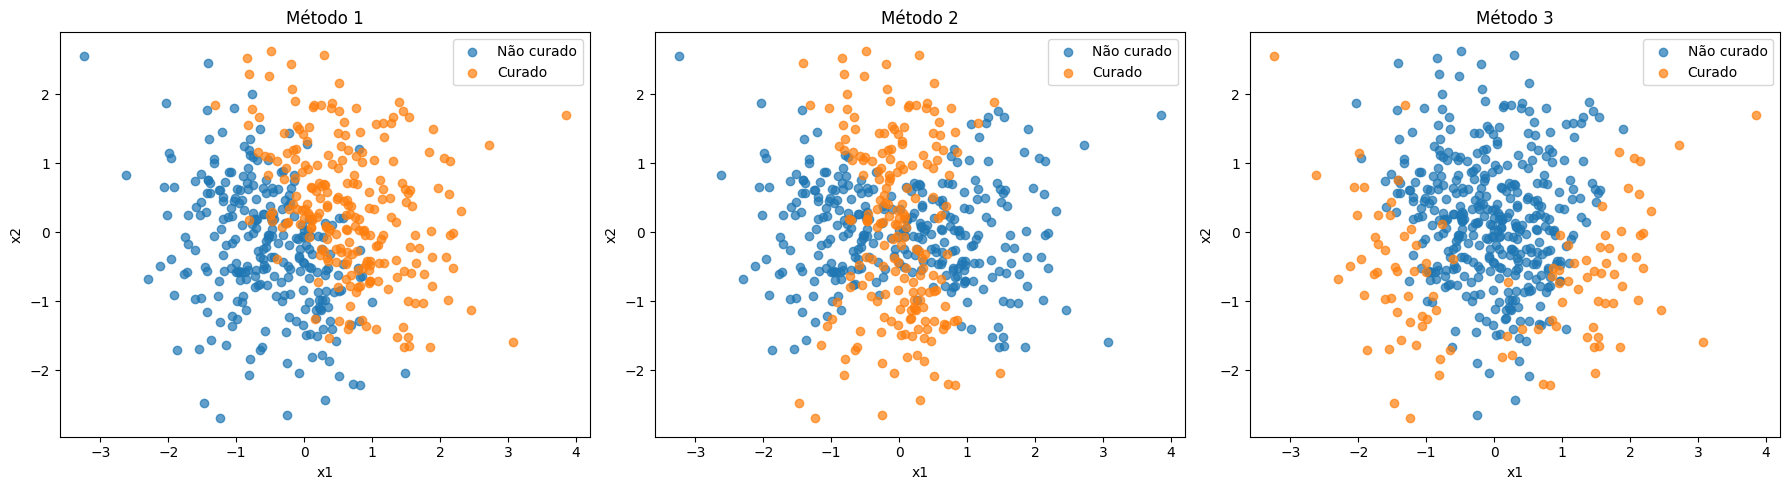

In [74]:
# plot methods for each data

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for method in [1, 2, 3]:

    df = simulate_pcm(
        n=500,
        method=method,
        seed=42
    )

    ax = axes[method - 1]

    cured = df[df["cured"] == 1]
    uncured = df[df["cured"] == 0]

    # plot uncured
    ax.scatter(
        uncured["x1"],
        uncured["x2"],
        alpha=0.7,
        label="Não curado"
    )

    # plot cured
    ax.scatter(
        cured["x1"],
        cured["x2"],
        alpha=0.7,
        label="Curado"
    )

    ax.set_title(f"Método {method}")
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.legend()

plt.tight_layout()
plt.show()